# Pretrained → Finetune notebook scaffold

Scaffold for the pretrained→finetune experiments: baseline pretraining on movies released up to 2004, zero-shot eval on yearly buckets 2005–2019, and finetune variants. No training runs are executed yet; this notebook only sets up sections, configs, and helper stubs so we can plug in runs later.

## Outline
- Intro & goals
- Imports & config
- Data split logic (<=2004 pretrain, 2005–2019 eval buckets, post-2005 aggregate)
- Training/Eval helpers (features, loaders, metrics, checkpoints)
- Pretraining run stub
- Zero-shot eval stub
- Finetune variant stubs (full, head-only, gradual unfreeze, adapters/LoRA placeholder)
- Post-FT eval stub
- Results aggregation stub
- Plotting stub
- Reporting/notes

In [51]:
from pathlib import Path
from dataclasses import dataclass, asdict, field
from typing import Dict, List, Tuple

import json
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
ARTIFACT_ROOT = NOTEBOOK_DIR / "artifacts" / "pretrained_finetune"

from src.data.constants import CAT_COLS, LOG_COLS, NUMERIC_COLS, TARGET_COL
from src.data.load_data import filter_and_group, load_raw, train_val_test_split
from src.data.encode_features import (
    apply_frequency_encoders,
    apply_log1p,
    apply_rare_grouping,
    apply_scaler,
    fill_unknown_categories,
    prepare_features,
)
from src.models.model import TabularRegressor
from src.models.train import TrainConfig, make_loaders, train_model
from src.utils.checkpoints import save_checkpoint, load_checkpoint
from src.utils.plotting import boxplot_by_group


@dataclass
class NotebookPaths:
    root: Path = ARTIFACT_ROOT
    checkpoints: Path = field(init=False)
    results: Path = field(init=False)
    plots: Path = field(init=False)

    def __post_init__(self):
        self.root.mkdir(parents=True, exist_ok=True)
        self.checkpoints = self.root / "checkpoints"
        self.results = self.root / "results"
        self.plots = self.root / "plots"
        for path in (self.checkpoints, self.results, self.plots):
            path.mkdir(parents=True, exist_ok=True)


@dataclass
class ExperimentConfig:
    seed: int = 42
    train_end_year: int = 2005
    eval_years: List[int] = field(default_factory=lambda: list(range(2005, 2020)))
    batch_size: int = 64
    base_lr: float = 1e-3
    finetune_lr: float = 5e-4
    epoch_sweep: Tuple[int, ...] = (1, 3, 5, 10)
    pretrain_epochs: int = 100
    data_fracs: Tuple[float, ...] = (1.0,)
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


paths = NotebookPaths()
cfg = ExperimentConfig()

def set_deterministic_seed(seed: int, deterministic: bool = True) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        try:
            torch.use_deterministic_algorithms(True)
        except Exception:
            pass


set_deterministic_seed(cfg.seed)
CONFIG_SNAPSHOT_PATH = paths.results / "config.json"
CONFIG_SNAPSHOT_PATH.write_text(json.dumps({**asdict(cfg), "artifact_root": str(paths.root)}, indent=2))

# Base template; set input_dim after feature prep.
BASE_SHARED_TRAIN = TrainConfig(
    mode="shared",
    input_dim=None,
    encoder_hidden=(128, 64),
    head_hidden=(),
    dropout=0.1,
    lr=cfg.base_lr,
    epochs=max(cfg.epoch_sweep),
    batch_size=cfg.batch_size,
    device=cfg.device,
)

## Data split logic
Temporal splits to match the plan: pretraining on movies with `year <= 2005`; evaluation buckets for each year 2005–2020 plus an aggregated post-2005 set. Helpers below keep preprocessing consistent with the baseline encoder/head stack.

Plan for splits/loaders:
- Pretrain set = filtered rows with `year <= 2005` (baseline filters only; no leakage across buckets).
- Eval buckets = one per `cfg.eval_years` year; `post_2005_plus` aggregates all `year > 2005` rows for finetune targets and overall metrics.
- Use deterministic seed in any downsampling to keep sweeps reproducible.
- Reuse the baseline feature pipeline (`prepare_features` artifacts) so each bucket is encoded the same way as pretraining.

In [76]:
def load_and_split(cfg: ExperimentConfig) -> Dict[str, object]:
    """Load raw data, apply baseline filters, and build temporal buckets."""
    raw_df = load_raw()
    clean_df = filter_and_group(raw_df)

    pretrain_df = clean_df[clean_df["year"] <= cfg.train_end_year].copy()
    eval_buckets = {year: clean_df[clean_df["year"] == year].copy() for year in cfg.eval_years}
    eval_buckets["post_2005_plus"] = clean_df[clean_df["year"] > cfg.train_end_year].copy()

    return {
        "raw": raw_df,
        "clean": clean_df,
        "pretrain": pretrain_df,
        "eval_buckets": eval_buckets,
    }


def maybe_downsample(df: pd.DataFrame, frac: float, seed: int) -> pd.DataFrame:
    """Optional downsample to support data-fraction sweeps."""
    if frac >= 1.0:
        return df
    return df.sample(frac=frac, random_state=seed)


def maybe_downsample_splits(
    splits: Dict[str, pd.DataFrame],
    frac: float,
    seed: int,
) -> Dict[str, pd.DataFrame]:
    """Downsample only the training split; keep val/test unchanged."""
    if frac >= 1.0:
        return splits
    updated = splits.copy()
    if "train" in updated:
        updated["train"] = updated["train"].sample(frac=frac, random_state=seed)
    return updated


DATA_SPLIT_ROOT = PROJECT_ROOT / "data"
PRETRAIN_SPLIT_DIR = DATA_SPLIT_ROOT / "processed" / "up_to_2005"
POST2005_SPLIT_DIR = DATA_SPLIT_ROOT / "processed" / "from_2005"
YEAR_BUCKET_DIR = POST2005_SPLIT_DIR / "by_year"


def _saved_splits_exist() -> bool:
    return (PRETRAIN_SPLIT_DIR / "train.csv").exists() and (POST2005_SPLIT_DIR / "post_2005_plus_train.csv").exists()


def persist_split_csvs(splits: Dict[str, object], cfg: ExperimentConfig, overwrite: bool = False) -> Dict[str, Path]:
    """Persist pre-split CSVs for pretrain and post-2005 data, plus yearly buckets."""
    PRETRAIN_SPLIT_DIR.mkdir(parents=True, exist_ok=True)
    POST2005_SPLIT_DIR.mkdir(parents=True, exist_ok=True)
    YEAR_BUCKET_DIR.mkdir(parents=True, exist_ok=True)

    out_paths = {}

    pretrain_train = PRETRAIN_SPLIT_DIR / "train.csv"
    if overwrite or not pretrain_train.exists():
        pretrain_df = splits["pretrain"].copy()
        train_df, val_df, test_df = train_val_test_split(pretrain_df, seed=cfg.seed)
        train_df.to_csv(PRETRAIN_SPLIT_DIR / "train.csv", index=False)
        val_df.to_csv(PRETRAIN_SPLIT_DIR / "val.csv", index=False)
        test_df.to_csv(PRETRAIN_SPLIT_DIR / "test.csv", index=False)
        out_paths.update(
            {
                "pretrain_train": PRETRAIN_SPLIT_DIR / "train.csv",
                "pretrain_val": PRETRAIN_SPLIT_DIR / "val.csv",
                "pretrain_test": PRETRAIN_SPLIT_DIR / "test.csv",
            }
        )

    post_full = POST2005_SPLIT_DIR / "post_2005_plus.csv"
    if overwrite or not post_full.exists():
        post_df = splits["eval_buckets"]["post_2005_plus"].copy()
        post_df.to_csv(post_full, index=False)
        train_df, val_df, test_df = train_val_test_split(post_df, seed=cfg.seed)
        train_df.to_csv(POST2005_SPLIT_DIR / "post_2005_plus_train.csv", index=False)
        val_df.to_csv(POST2005_SPLIT_DIR / "post_2005_plus_val.csv", index=False)
        test_df.to_csv(POST2005_SPLIT_DIR / "post_2005_plus_test.csv", index=False)
        out_paths.update(
            {
                "post_2005_plus": post_full,
                "post_2005_plus_train": POST2005_SPLIT_DIR / "post_2005_plus_train.csv",
                "post_2005_plus_val": POST2005_SPLIT_DIR / "post_2005_plus_val.csv",
                "post_2005_plus_test": POST2005_SPLIT_DIR / "post_2005_plus_test.csv",
            }
        )

    for year, df in splits["eval_buckets"].items():
        if year == "post_2005_plus":
            continue
        year_path = YEAR_BUCKET_DIR / f"{year}.csv"
        if overwrite or not year_path.exists():
            df.to_csv(year_path, index=False)
            out_paths[f"year_{year}"] = year_path

    return out_paths


def load_saved_splits(cfg: ExperimentConfig) -> Dict[str, object]:
    """Load persisted CSV splits into the standard split dict format."""
    pretrain = pd.read_csv(PRETRAIN_SPLIT_DIR / "train.csv")
    pretrain_val = pd.read_csv(PRETRAIN_SPLIT_DIR / "val.csv")
    pretrain_test = pd.read_csv(PRETRAIN_SPLIT_DIR / "test.csv")

    post_full = pd.read_csv(POST2005_SPLIT_DIR / "post_2005_plus.csv")

    eval_buckets = {year: pd.read_csv(YEAR_BUCKET_DIR / f"{year}.csv") for year in cfg.eval_years}
    eval_buckets["post_2005_plus"] = post_full

    return {
        "pretrain": pretrain,
        "pretrain_val": pretrain_val,
        "pretrain_test": pretrain_test,
        "eval_buckets": eval_buckets,
    }


def load_post2005_split_dfs() -> Dict[str, pd.DataFrame]:
    """Load saved post-2005 train/val/test CSVs."""
    return {
        "train": pd.read_csv(POST2005_SPLIT_DIR / "post_2005_plus_train.csv"),
        "val": pd.read_csv(POST2005_SPLIT_DIR / "post_2005_plus_val.csv"),
        "test": pd.read_csv(POST2005_SPLIT_DIR / "post_2005_plus_test.csv"),
    }


if _saved_splits_exist():
    SPLITS = load_saved_splits(cfg)
else:
    SPLITS = load_and_split(cfg)
    persist_split_csvs(SPLITS, cfg)

pretrain_total = len(SPLITS.get("pretrain", []))
pretrain_total += len(SPLITS.get("pretrain_val", []))
pretrain_total += len(SPLITS.get("pretrain_test", []))

print(
    f"Pretrain size (<= {cfg.train_end_year}): {pretrain_total}; "
    f"Post-2005+: {len(SPLITS['eval_buckets']['post_2005_plus'])}"
)


Pretrain size (<= 2005): 3250; Post-2005+: 2185


## Training / evaluation helpers
Feature prep, loader construction, metric computation, and checkpoint helpers reused across pretraining, zero-shot eval, and fine-tuning variants.

In [53]:
def build_shared_features(df: pd.DataFrame, seed: int) -> Dict[str, object]:
    """Baseline feature pipeline reused for pretraining and eval.

    Returns X/y splits plus preprocessing artifacts (encoders, category_maps, scaler).
    """
    train_df, val_df, test_df = train_val_test_split(df, seed=seed)
    return build_shared_features_from_splits(train_df, val_df, test_df)


def build_shared_features_from_splits(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
) -> Dict[str, object]:
    """Feature pipeline given explicit train/val/test splits."""
    X_train, X_val, X_test, y_train, y_val, y_test, artifacts = prepare_features(train_df, val_df, test_df)
    return {
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "artifacts": artifacts,
    }


def apply_feature_artifacts(df: pd.DataFrame, artifacts: Dict[str, object]) -> Tuple[np.ndarray, np.ndarray]:
    """Transform a new dataframe using saved frequency encoders and scaler."""
    df_cat = fill_unknown_categories(df, CAT_COLS)
    df_cat = apply_rare_grouping(df_cat, artifacts["category_maps"])
    df_num = apply_log1p(df, LOG_COLS)

    enc_df = apply_frequency_encoders(df_cat, artifacts["encoders"])
    num_scaled = apply_scaler(df_num, artifacts["scaler"], NUMERIC_COLS)
    X = np.hstack([num_scaled, enc_df[CAT_COLS].to_numpy()]).astype(np.float32)
    y = np.log1p(df[TARGET_COL].values).astype(np.float32)
    return X, y


def tensor_loader_from_arrays(X: np.ndarray, y: np.ndarray, batch_size: int, shuffle: bool) -> torch.utils.data.DataLoader:
    dataset = torch.utils.data.TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def evaluate_shared(model: torch.nn.Module, loader: torch.utils.data.DataLoader, device: str) -> Dict[str, float]:
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb).squeeze()
            preds.append(pred.cpu())
            targets.append(yb.cpu())
    preds = torch.cat(preds)
    targets = torch.cat(targets)
    mse = F.mse_loss(preds, targets).item()
    mae = torch.mean(torch.abs(preds - targets)).item()
    rmse = mse ** 0.5
    return {"mse": mse, "mae": mae, "rmse": rmse}


def train_config_for_shared(input_dim: int, epochs: int, lr: float, freeze_encoder_epochs: int = 0) -> TrainConfig:
    """Clone the shared template with input_dim/lr/epochs overrides."""
    return TrainConfig(
        mode="shared",
        input_dim=input_dim,
        encoder_hidden=BASE_SHARED_TRAIN.encoder_hidden,
        head_hidden=BASE_SHARED_TRAIN.head_hidden,
        dropout=BASE_SHARED_TRAIN.dropout,
        lr=lr,
        epochs=epochs,
        batch_size=BASE_SHARED_TRAIN.batch_size,
        device=BASE_SHARED_TRAIN.device,
        freeze_encoder_epochs=freeze_encoder_epochs,
    )


def persist_artifacts(artifacts: Dict[str, object], path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(artifacts, path)


def load_artifacts(path: Path) -> Dict[str, object]:
    # Artifacts include pandas objects; allow full unpickling for trusted local files.
    import pandas as pd

    with torch.serialization.safe_globals([pd.Series, pd.Index]):
        return torch.load(path, weights_only=False)


## Pretraining (shared encoder + head)
Single run stub that trains on `year <= 2005`, captures metrics, and saves the checkpoint + preprocessing artifacts for reuse in zero-shot and fine-tuning variants.

Baseline pretraining plan/logging:
- Data: use the `pretrain` split (<=2005), with optional `data_frac` downsampling for budget sweeps.
- Features: fit baseline encoders/scaler once on the pretrain split; store artifacts for reuse.
- Model: shared encoder+head config (`TrainConfig`) with `epochs` from sweep (default max of `cfg.epoch_sweep`) and `lr=cfg.base_lr`.
- Logging: track train/val loss, RMSE/MAE per epoch, wall-clock, and config snapshot; return `history` and persist under `paths.results`.
- Checkpoints: save weights to `paths.checkpoints` with epoch/data_frac in filename; persist preprocessing artifacts alongside (single shared artifact file).

In [54]:
def run_pretrain_shared(splits: Dict[str, object], cfg: ExperimentConfig, paths: NotebookPaths, data_frac: float = 1.0, epochs: int | None = None):
    """Train the shared encoder+head on <=2005 data and persist artifacts.

    Returns model, history, checkpoint path, and preprocessing artifacts.
    """
    train_df = splits.get("pretrain")
    val_df = splits.get("pretrain_val")
    test_df = splits.get("pretrain_test")
    if train_df is None or val_df is None or test_df is None:
        pre_df = maybe_downsample(splits["pretrain"], frac=data_frac, seed=cfg.seed)
        feats = build_shared_features(pre_df, seed=cfg.seed)
    else:
        split_dfs = maybe_downsample_splits(
            {
                "train": train_df,
                "val": val_df,
                "test": test_df,
            },
            frac=data_frac,
            seed=cfg.seed,
        )
        feats = build_shared_features_from_splits(
            split_dfs["train"],
            split_dfs["val"],
            split_dfs["test"],
        )

    train_cfg = train_config_for_shared(
        input_dim=feats["X_train"].shape[1],
        epochs=epochs or BASE_SHARED_TRAIN.epochs,
        lr=cfg.base_lr,
    )
    train_loader, val_loader = make_loaders(
        feats["X_train"],
        feats["y_train"],
        feats["X_val"],
        feats["y_val"],
        batch_size=train_cfg.batch_size,
        separate=False,
    )
    model, history = train_model(train_cfg, train_loader, val_loader, X_is_separate=False)

    ckpt_path = paths.checkpoints / f"pretrain_shared_epochs{train_cfg.epochs}_frac{data_frac}.pt"
    save_checkpoint(model, ckpt_path)
    artifacts_path = paths.checkpoints / "pretrain_shared_artifacts.pt"
    persist_artifacts(feats["artifacts"], artifacts_path)

    return {
        "model": model,
        "history": history,
        "train_cfg": train_cfg,
        "ckpt_path": ckpt_path,
        "artifacts_path": artifacts_path,
        "features": feats,
    }


# Placeholder to hold a pretraining result when we run it later.
PRETRAIN_RUN = None  # set to the returned dict from run_pretrain_shared(...) once executed

In [55]:
# Execute baseline pretraining (toggle RUN_PRETRAIN to skip)
RUN_PRETRAIN = True
PRETRAIN_EPOCHS = cfg.pretrain_epochs
DATA_FRAC = 1.0

if RUN_PRETRAIN:
    PRETRAIN_RUN = run_pretrain_shared(
        SPLITS,
        cfg,
        paths,
        data_frac=DATA_FRAC,
        epochs=PRETRAIN_EPOCHS,
    )
    hist_df = pd.DataFrame(PRETRAIN_RUN["history"])
    hist_path = paths.results / f"pretrain_history_epochs{PRETRAIN_EPOCHS}_frac{DATA_FRAC}.csv"
    hist_df.to_csv(hist_path, index=False)
    print(f"Pretraining complete; history saved to {hist_path}")
else:
    print("Skipped pretraining run.")

Epoch 001 | train MSE 245.5267 | val MSE 174.0351 | train MAE 15.5061 | val MAE 13.0161
Epoch 010 | train MSE 5.4895 | val MSE 3.6350 | train MAE 1.8229 | val MAE 1.4659
Epoch 020 | train MSE 3.9517 | val MSE 2.2618 | train MAE 1.5640 | val MAE 1.1399
Epoch 030 | train MSE 3.0156 | val MSE 1.5400 | train MAE 1.3681 | val MAE 0.8992
Epoch 040 | train MSE 2.8530 | val MSE 1.3295 | train MAE 1.3358 | val MAE 0.8149
Epoch 050 | train MSE 2.8077 | val MSE 1.3154 | train MAE 1.3078 | val MAE 0.8069
Epoch 060 | train MSE 2.6132 | val MSE 1.2328 | train MAE 1.2561 | val MAE 0.7671
Epoch 070 | train MSE 2.6953 | val MSE 1.2580 | train MAE 1.2898 | val MAE 0.7652
Epoch 080 | train MSE 2.6358 | val MSE 1.2913 | train MAE 1.2641 | val MAE 0.8116
Epoch 090 | train MSE 2.6551 | val MSE 1.2274 | train MAE 1.2742 | val MAE 0.7651
Epoch 100 | train MSE 2.4851 | val MSE 1.2979 | train MAE 1.2289 | val MAE 0.8030
Pretraining complete; history saved to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Docum

Saved pretraining curves to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\pretrained_finetune\plots\pretrain_history.png


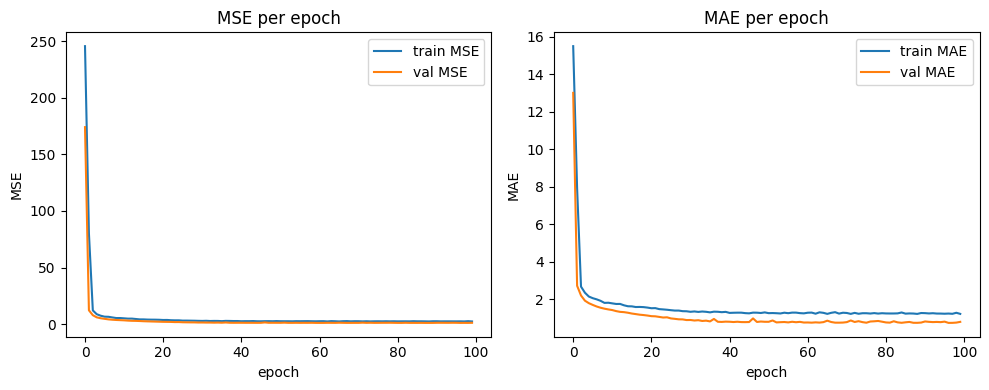

In [56]:
import matplotlib.pyplot as plt
from pathlib import Path


def plot_pretrain_history(history, out_dir: Path | None = None, show: bool = False):
    """Plot train/val MSE and MAE curves from history dict/CSV/DataFrame."""
    if history is None:
        print("No history provided.")
        return None

    if isinstance(history, (str, Path)):
        df = pd.read_csv(history)
    elif isinstance(history, dict):
        df = pd.DataFrame(history)
    else:
        df = history.copy()

    if df.empty:
        print("History is empty; nothing to plot.")
        return None

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
    axes[0].plot(df["train_loss"], label="train MSE")
    axes[0].plot(df["val_loss"], label="val MSE")
    axes[0].set_title("MSE per epoch")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("MSE")
    axes[0].legend()

    axes[1].plot(df["train_mae"], label="train MAE")
    axes[1].plot(df["val_mae"], label="val MAE")
    axes[1].set_title("MAE per epoch")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("MAE")
    axes[1].legend()

    plt.tight_layout()
    saved_path = None
    if out_dir is not None:
        out_dir.mkdir(parents=True, exist_ok=True)
        saved_path = out_dir / "pretrain_history.png"
        fig.savefig(saved_path, dpi=150, bbox_inches="tight")
        print(f"Saved pretraining curves to {saved_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return saved_path, df


# Auto-plot using in-memory history or latest saved history
if PRETRAIN_RUN and PRETRAIN_RUN.get("history"):
    plot_pretrain_history(PRETRAIN_RUN["history"], paths.plots, show=True)
else:
    history_files = sorted(paths.results.glob("pretrain_history_*.csv"))
    if history_files:
        plot_pretrain_history(history_files[-1], paths.plots)
    else:
        print("No pretraining history available to plot.")

## Zero-shot evaluation
Stub for evaluating the pretrained checkpoint on yearly buckets (2005–2020) and the aggregated post-2005 set. Uses the saved preprocessing artifacts for consistent encoding.

Zero-shot eval plan/storage:
- Load pretrained checkpoint + feature artifacts (from in-memory run or disk) and move to `cfg.device`.
- For each eval bucket (per-year + `post_2005_plus`), transform with saved encoders/scaler, build non-shuffled loader, and compute RMSE/MAE/MSE.
- Record per-bucket metrics and `n` to a tidy `DataFrame`; save to `paths.results/zero_shot.csv` (and optionally JSON if needed).
- Keep outputs reusable for plots and comparison against finetuned variants (add `method=zero_shot`).

In [57]:
def restore_pretrained(train_cfg: TrainConfig, ckpt_path: Path) -> torch.nn.Module:
    """Reload a pretrained model from disk using the saved train config."""
    model = TabularRegressor(
        mode=train_cfg.mode,
        input_dim=train_cfg.input_dim,
        num_dim=train_cfg.num_dim,
        cat_dim=train_cfg.cat_dim,
        encoder_hidden=train_cfg.encoder_hidden,
        head_hidden=train_cfg.head_hidden,
        dropout=train_cfg.dropout,
    ).to(train_cfg.device)
    load_checkpoint(model, ckpt_path, map_location=train_cfg.device)
    return model


def evaluate_zero_shot(pretrain_run: Dict[str, object] | None, splits: Dict[str, object], cfg: ExperimentConfig, paths: NotebookPaths):
    """Evaluate the pretrained checkpoint on each yearly bucket and post-2005 aggregate."""
    run = pretrain_run or PRETRAIN_RUN
    if run is None:
        print("No pretraining run available yet. Execute run_pretrain_shared(...) first or load from disk.")
        return None

    artifacts = run.get("features", {}).get("artifacts")
    if artifacts is None:
        artifacts = load_artifacts(paths.checkpoints / "pretrain_shared_artifacts.pt")

    model = run.get("model")
    if model is None:
        model = restore_pretrained(run["train_cfg"], run["ckpt_path"])
    device = run.get("train_cfg", BASE_SHARED_TRAIN).device
    model.to(device)

    results = []
    for year_key, df in splits["eval_buckets"].items():
        if df.empty:
            continue
        X, y = apply_feature_artifacts(df, artifacts)
        loader = tensor_loader_from_arrays(X, y, batch_size=cfg.batch_size, shuffle=False)
        metrics = evaluate_shared(model, loader, device)
        results.append(
            {
                "method": "zero_shot",
                "year": year_key,
                **metrics,
                "n": len(df),
            }
        )

    results_df = pd.DataFrame(results)
    out_path = paths.results / "zero_shot.csv"
    results_df.to_csv(out_path, index=False)
    return results_df, out_path


In [58]:
# Run zero-shot evaluation on yearly buckets using the pretrained checkpoint
RUN_ZERO_SHOT = True

if RUN_ZERO_SHOT:
    zs = evaluate_zero_shot(PRETRAIN_RUN, SPLITS, cfg, paths)
    if zs is not None:
        zero_shot_df, zero_path = zs
        print(zero_shot_df.head())
        print(f"Zero-shot metrics saved to {zero_path}")
    else:
        print("Zero-shot eval skipped; no pretrained checkpoint available.")
else:
    print("Skipped zero-shot eval.")

      method  year       mse       mae      rmse    n
0  zero_shot  2005  0.804950  0.648245  0.897190  170
1  zero_shot  2006  0.706553  0.594920  0.840567  163
2  zero_shot  2007  0.789651  0.604272  0.888623  157
3  zero_shot  2008  1.030311  0.646610  1.015042  171
4  zero_shot  2009  1.428935  0.799885  1.195381  171
Zero-shot metrics saved to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\pretrained_finetune\results\zero_shot.csv


      method  year  sample       mse       mae      rmse   n
0  zero_shot  2005       0  0.702953  0.650013  0.838423  34
1  zero_shot  2005       1  0.925705  0.693323  0.962135  34
2  zero_shot  2005       2  1.323250  0.744364  1.150326  34
3  zero_shot  2005       3  1.892882  0.911310  1.375821  34
4  zero_shot  2005       4  0.507763  0.583404  0.712575  34
Sampled zero-shot metrics saved to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\pretrained_finetune\results\zero_shot_samples_ns50_frac0.2.csv


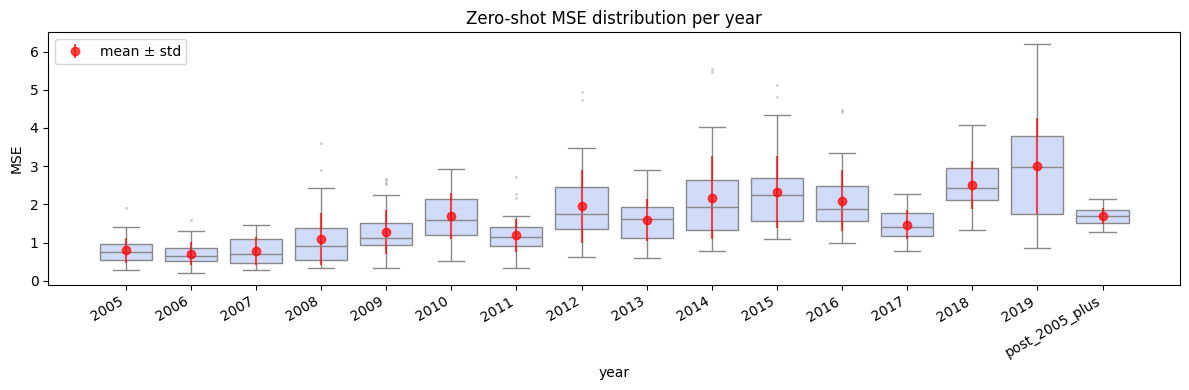

Saved boxplots to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\pretrained_finetune\plots\zero_shot_mse_boxplots.png


In [59]:
def evaluate_zero_shot_samples(
    pretrain_run: Dict[str, object] | None,
    splits: Dict[str, object],
    cfg: ExperimentConfig,
    paths: NotebookPaths,
    n_samples: int = 10,
    sample_frac: float = 0.5,
    replace: bool = True,
    seed: int | None = None,
):
    """Repeatedly sample each eval bucket and compute metrics for boxplots."""
    run = pretrain_run or PRETRAIN_RUN
    if run is None:
        print("No pretraining run available; run pretraining first or load checkpoint.")
        return None

    rng_seed = seed if seed is not None else cfg.seed

    artifacts = run.get("features", {}).get("artifacts")
    if artifacts is None:
        artifacts = load_artifacts(paths.checkpoints / "pretrain_shared_artifacts.pt")

    model = run.get("model")
    if model is None:
        model = restore_pretrained(run["train_cfg"], run["ckpt_path"])
    device = run.get("train_cfg", BASE_SHARED_TRAIN).device
    model.to(device)

    results = []
    for year_key, df in splits["eval_buckets"].items():
        if df.empty:
            continue
        for i in range(n_samples):
            sample_df = df.sample(
                frac=sample_frac,
                replace=replace,
                random_state=rng_seed + i,
            )
            if sample_df.empty:
                continue
            X, y = apply_feature_artifacts(sample_df, artifacts)
            loader = tensor_loader_from_arrays(X, y, batch_size=cfg.batch_size, shuffle=False)
            metrics = evaluate_shared(model, loader, device)
            results.append(
                {
                    "method": "zero_shot",
                    "year": year_key,
                    "sample": i,
                    **metrics,
                    "n": len(sample_df),
                }
            )

    samples_df = pd.DataFrame(results)
    if samples_df.empty:
        print("No sampled metrics produced.")
        return None

    out_path = paths.results / f"zero_shot_samples_ns{n_samples}_frac{sample_frac}.csv"
    samples_df.to_csv(out_path, index=False)
    return samples_df, out_path


def plot_zero_shot_boxplots(
    samples_df: pd.DataFrame,
    metric: str = "rmse",
    out_dir: Path | None = None,
    show: bool = False,
    prefix: str = "zero_shot",
    title_prefix: str = "Zero-shot",
):
    if samples_df is None or samples_df.empty:
        print("No sample data to plot.")
        return None

    samples_df = samples_df.assign(year_label=samples_df["year"].astype(str))
    save_path = out_dir / f"{prefix}_{metric}_boxplots.png" if out_dir else None

    _, _, summary = boxplot_by_group(
        samples_df,
        group_col="year_label",
        value_col=metric,
        order=None,  # util handles numeric-first ordering
        title=f"{title_prefix} {metric.upper()} distribution per year",
        xlabel="year",
        ylabel=metric.upper(),
        color="#c9d8ff",
        save_path=save_path,
        show=show,
    )

    if save_path:
        print(f"Saved boxplots to {save_path}")

    return save_path, summary


# Run sampled zero-shot eval + boxplots
RUN_ZERO_SHOT_SAMPLES = True
N_SAMPLES = 50
SAMPLE_FRAC = 0.2
SAMPLE_METRIC = "mse"
SHOW_ZERO_SHOT_PLOTS = True  # set True to display inline

if RUN_ZERO_SHOT_SAMPLES:
    zs_samples = evaluate_zero_shot_samples(
        PRETRAIN_RUN,
        SPLITS,
        cfg,
        paths,
        n_samples=N_SAMPLES,
        sample_frac=SAMPLE_FRAC,
        replace=True,
        seed=cfg.seed,
    )
    if zs_samples is not None:
        samples_df, samples_path = zs_samples
        print(samples_df.head())
        print(f"Sampled zero-shot metrics saved to {samples_path}")
        plot_zero_shot_boxplots(
            samples_df,
            metric=SAMPLE_METRIC,
            out_dir=paths.plots,
            show=SHOW_ZERO_SHOT_PLOTS,
        )
    else:
        print("Skipped sampled zero-shot eval; no data produced.")
else:
    print("Skipped zero-shot sampling.")


## Fine-tuning variants (stubs)
Placeholders for full finetuning, head-only, gradual unfreeze, and adapters/LoRA. These functions will reuse the pretrained checkpoint + artifacts and track wall-clock and configs for later aggregation.

In [60]:
import time

from src.models.heads import RegressionHead


FINETUNE_VARIANTS = {
    "full_finetune": {
        "freeze_encoder_epochs": 0,
        "reinit_head": False,
        "description": "Unfreeze everything; shorter schedule + lower LR",
    },
    "head_only": {
        "freeze_encoder_epochs": None,  # keep encoder frozen for all epochs
        "reinit_head": True,
        "description": "Freeze encoder, optionally reinit head",
    },
    "gradual_unfreeze": {
        "freeze_encoder_epochs": 1,
        "reinit_head": False,
        "description": "Start frozen, unfreeze after 1 epoch (adjust as needed)",
    },
    "adapters_lora": {
        "freeze_encoder_epochs": 0,
        "reinit_head": False,
        "description": "Placeholder for lightweight adapters/LoRA blocks",
    },
}


def prep_finetune_arrays_from_splits(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    artifacts: Dict[str, object],
) -> Dict[str, np.ndarray]:
    """Transform pre-split post-2005 data using pretrained artifacts (no refit)."""
    X_train, y_train = apply_feature_artifacts(train_df, artifacts)
    X_val, y_val = apply_feature_artifacts(val_df, artifacts)
    X_test, y_test = apply_feature_artifacts(test_df, artifacts)
    return {
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
    }


def _set_encoder_requires_grad(model: torch.nn.Module, requires_grad: bool) -> None:
    for param in model.encoder.parameters():
        param.requires_grad = requires_grad


def _make_optimizer(model: torch.nn.Module, lr: float) -> torch.optim.Optimizer:
    params = [p for p in model.parameters() if p.requires_grad]
    return torch.optim.Adam(params, lr=lr)


def _reinit_head(model: torch.nn.Module, head_hidden: Tuple[int, ...], dropout: float) -> None:
    first_linear = next((m for m in model.head.modules() if isinstance(m, torch.nn.Linear)), None)
    input_dim = first_linear.in_features if first_linear is not None else None
    model.head = RegressionHead(input_dim, hidden_dims=head_hidden, dropout=dropout).to(next(model.parameters()).device)


def finetune_shared_model(
    model: torch.nn.Module,
    train_cfg: TrainConfig,
    train_loader: torch.utils.data.DataLoader,
    val_loader: torch.utils.data.DataLoader,
) -> Tuple[torch.nn.Module, Dict[str, List[float]], float]:
    """Finetune loop for shared encoder models loaded from a pretrained checkpoint."""
    loss_fn = torch.nn.MSELoss()
    history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}

    if train_cfg.freeze_encoder_epochs and train_cfg.freeze_encoder_epochs > 0:
        _set_encoder_requires_grad(model, False)

    opt = _make_optimizer(model, train_cfg.lr)
    start = time.perf_counter()

    for epoch in range(1, train_cfg.epochs + 1):
        model.train()
        train_losses, train_mae = [], []
        for xb, yb in train_loader:
            xb = xb.to(train_cfg.device)
            yb = yb.to(train_cfg.device)
            pred = model(xb).unsqueeze(1)
            loss = loss_fn(pred, yb.unsqueeze(1))
            opt.zero_grad()
            loss.backward()
            opt.step()
            train_losses.append(loss.item())
            train_mae.append(torch.abs(pred - yb.unsqueeze(1)).mean().item())

        model.eval()
        val_losses, val_mae = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(train_cfg.device)
                yb = yb.to(train_cfg.device)
                pred = model(xb).unsqueeze(1)
                val_losses.append(loss_fn(pred, yb.unsqueeze(1)).item())
                val_mae.append(torch.abs(pred - yb.unsqueeze(1)).mean().item())

        history["train_loss"].append(sum(train_losses) / len(train_losses))
        history["val_loss"].append(sum(val_losses) / len(val_losses))
        history["train_mae"].append(sum(train_mae) / len(train_mae))
        history["val_mae"].append(sum(val_mae) / len(val_mae))

        if epoch % 10 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:03d} | train MSE {history['train_loss'][-1]:.4f} | "
                f"val MSE {history['val_loss'][-1]:.4f} | "
                f"train MAE {history['train_mae'][-1]:.4f} | "
                f"val MAE {history['val_mae'][-1]:.4f}"
            )

        if train_cfg.freeze_encoder_epochs and epoch == train_cfg.freeze_encoder_epochs:
            _set_encoder_requires_grad(model, True)
            opt = _make_optimizer(model, train_cfg.lr)

    wall_time_s = time.perf_counter() - start
    return model, history, wall_time_s


def run_finetune_variant(
    name: str,
    splits: Dict[str, object],
    cfg: ExperimentConfig,
    paths: NotebookPaths,
    pretrain_run: Dict[str, object] | None,
    data_frac: float,
    epochs: int,
    lr: float,
):
    """Run a finetune variant starting from the pretrained checkpoint."""
    variant = FINETUNE_VARIANTS[name]
    run = pretrain_run or PRETRAIN_RUN
    if run is None:
        print("No pretrained checkpoint yet; run pretraining first.")
        return None

    set_deterministic_seed(cfg.seed)

    if name != "full_finetune":
        print(f"Variant '{name}' not implemented yet. Start with full_finetune first.")
        return None

    artifacts = run.get("features", {}).get("artifacts")
    if artifacts is None:
        artifacts = load_artifacts(paths.checkpoints / "pretrain_shared_artifacts.pt")

    split_dfs = load_post2005_split_dfs()
    split_dfs = maybe_downsample_splits(split_dfs, frac=data_frac, seed=cfg.seed)
    ft_arrays = prep_finetune_arrays_from_splits(
        split_dfs["train"],
        split_dfs["val"],
        split_dfs["test"],
        artifacts,
    )

    train_cfg = train_config_for_shared(
        input_dim=ft_arrays["X_train"].shape[1],
        epochs=epochs,
        lr=lr,
        freeze_encoder_epochs=variant["freeze_encoder_epochs"] or 0,
    )

    train_loader, val_loader = make_loaders(
        ft_arrays["X_train"],
        ft_arrays["y_train"],
        ft_arrays["X_val"],
        ft_arrays["y_val"],
        batch_size=train_cfg.batch_size,
        separate=False,
    )

    model = restore_pretrained(run["train_cfg"], run["ckpt_path"])
    if variant["reinit_head"]:
        _reinit_head(model, head_hidden=train_cfg.head_hidden, dropout=train_cfg.dropout)

    model, history, wall_time_s = finetune_shared_model(model, train_cfg, train_loader, val_loader)

    test_loader = tensor_loader_from_arrays(
        ft_arrays["X_test"],
        ft_arrays["y_test"],
        batch_size=train_cfg.batch_size,
        shuffle=False,
    )
    test_metrics = evaluate_shared(model, test_loader, train_cfg.device)

    ckpt_path = paths.checkpoints / f"finetune_{name}_epochs{epochs}_frac{data_frac}.pt"
    save_checkpoint(model, ckpt_path)

    hist_df = pd.DataFrame(history)
    hist_path = paths.results / f"finetune_{name}_history_epochs{epochs}_frac{data_frac}.csv"
    hist_df.to_csv(hist_path, index=False)

    config_payload = {
        **asdict(train_cfg),
        "variant": name,
        "description": variant["description"],
        "data_frac": data_frac,
        "epochs": epochs,
        "lr": lr,
        "pretrain_ckpt": str(run["ckpt_path"]),
        "wall_time_s": wall_time_s,
    }
    config_path = paths.results / f"finetune_{name}_config_epochs{epochs}_frac{data_frac}.json"
    config_path.write_text(json.dumps(config_payload, indent=2))

    return {
        "variant": name,
        "description": variant["description"],
        "data_frac": data_frac,
        "epochs": epochs,
        "lr": lr,
        "freeze_encoder_epochs": train_cfg.freeze_encoder_epochs,
        "reinit_head": variant["reinit_head"],
        "n_train": len(ft_arrays["y_train"]),
        "n_val": len(ft_arrays["y_val"]),
        "n_test": len(ft_arrays["y_test"]),
        "model": model,
        "history": history,
        "train_cfg": train_cfg,
        "ckpt_path": ckpt_path,
        "artifacts_path": paths.checkpoints / "pretrain_shared_artifacts.pt",
        "wall_time_s": wall_time_s,
        "test_metrics": test_metrics,
        "hist_path": hist_path,
        "config_path": config_path,
    }


pd.DataFrame.from_dict(FINETUNE_VARIANTS, orient="index")

,freeze_encoder_epochs,reinit_head,description
full_finetune,0.0,False,Unfreeze everything; shorter schedule + lower LR
head_only,NaN,True,"Freeze encoder, optionally reinit head"
gradual_unfreeze,1.0,False,"Start frozen, unfreeze after 1 epoch (adjust a..."
adapters_lora,0.0,False,Placeholder for lightweight adapters/LoRA blocks


## Post-FT evaluation stub
Placeholder to reuse the zero-shot evaluation helper across finetuned checkpoints and annotate with method/epochs/data_frac/wall_time.

In [ ]:
def resolve_artifacts_and_model(
    run: Dict[str, object],
    paths: NotebookPaths,
) -> Tuple[torch.nn.Module, Dict[str, object], str]:
    """Resolve artifacts and model for any run (pretrain or finetune)."""
    artifacts = run.get("features", {}).get("artifacts")
    if artifacts is None:
        artifacts_path = run.get("artifacts_path") or (paths.checkpoints / "pretrain_shared_artifacts.pt")
        artifacts = load_artifacts(artifacts_path)

    model = run.get("model")
    if model is None:
        model = restore_pretrained(run["train_cfg"], run["ckpt_path"])

    device = run.get("train_cfg", BASE_SHARED_TRAIN).device
    model.to(device)
    return model, artifacts, device


def evaluate_model_on_buckets(
    model: torch.nn.Module,
    artifacts: Dict[str, object],
    splits: Dict[str, object],
    cfg: ExperimentConfig,
    method: str,
    extra_meta: Dict[str, object] | None = None,
) -> pd.DataFrame:
    """Evaluate a model on each bucket using shared preprocessing artifacts."""
    results = []
    for year_key, df in splits["eval_buckets"].items():
        if df.empty:
            continue
        X, y = apply_feature_artifacts(df, artifacts)
        loader = tensor_loader_from_arrays(X, y, batch_size=cfg.batch_size, shuffle=False)
        metrics = evaluate_shared(model, loader, cfg.device)
        row = {"method": method, "year": year_key, **metrics, "n": len(df)}
        if extra_meta:
            row.update(extra_meta)
        results.append(row)

    return pd.DataFrame(results)


def evaluate_bucket_samples(
    model: torch.nn.Module,
    artifacts: Dict[str, object],
    splits: Dict[str, object],
    cfg: ExperimentConfig,
    method: str,
    n_samples: int = 10,
    sample_frac: float = 0.5,
    replace: bool = True,
    seed: int | None = None,
    extra_meta: Dict[str, object] | None = None,
) -> pd.DataFrame:
    """Sample each bucket repeatedly and compute metrics (for boxplots)."""
    rng_seed = seed if seed is not None else cfg.seed
    results = []
    for year_key, df in splits["eval_buckets"].items():
        if df.empty:
            continue
        for i in range(n_samples):
            sample_df = df.sample(
                frac=sample_frac,
                replace=replace,
                random_state=rng_seed + i,
            )
            if sample_df.empty:
                continue
            X, y = apply_feature_artifacts(sample_df, artifacts)
            loader = tensor_loader_from_arrays(X, y, batch_size=cfg.batch_size, shuffle=False)
            metrics = evaluate_shared(model, loader, cfg.device)
            row = {
                "method": method,
                "year": year_key,
                "sample": i,
                **metrics,
                "n": len(sample_df),
            }
            if extra_meta:
                row.update(extra_meta)
            results.append(row)

    return pd.DataFrame(results)


def summarize_finetune_runs(finetune_runs: List[Dict[str, object]]) -> pd.DataFrame:
    """Flatten finetune run metadata + test metrics for efficiency plots."""
    rows = []
    for run in finetune_runs:
        metrics = run.get("test_metrics", {})
        rows.append(
            {
                "method": run.get("variant"),
                "epochs": run.get("epochs"),
                "data_frac": run.get("data_frac"),
                "lr": run.get("lr"),
                "wall_time_s": run.get("wall_time_s"),
                "test_mse": metrics.get("mse"),
                "test_mae": metrics.get("mae"),
                "test_rmse": metrics.get("rmse"),
            }
        )
    return pd.DataFrame(rows)


def plot_finetune_efficiency(
    runs_df: pd.DataFrame,
    metric: str = "rmse",
    out_dir: Path | None = None,
    show: bool = False,
):
    """Plot metric vs epochs for finetune runs."""
    if runs_df is None or runs_df.empty:
        print("No finetune runs to plot.")
        return None

    metric_col = f"test_{metric}"
    if metric_col not in runs_df.columns:
        print(f"Missing metric column: {metric_col}")
        return None

    from matplotlib.ticker import ScalarFormatter

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(runs_df["epochs"], runs_df[metric_col], marker="o")
    ax.set_title(f"Finetune efficiency: {metric.upper()} vs epochs")
    ax.set_xlabel("epochs")
    ax.set_ylabel(metric.upper())
    ax.set_xscale("symlog", linthresh=1)
    xticks = sorted(set(runs_df["epochs"].tolist()))
    ax.set_xticks(xticks)
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.grid(True, alpha=0.3)

    saved_path = None
    if out_dir is not None:
        out_dir.mkdir(parents=True, exist_ok=True)
        saved_path = out_dir / f"finetune_efficiency_{metric}.png"
        fig.savefig(saved_path, dpi=150, bbox_inches="tight")
        print(f"Saved efficiency plot to {saved_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return saved_path


def evaluate_finetune_run(
    finetune_run: Dict[str, object],
    splits: Dict[str, object],
    cfg: ExperimentConfig,
    paths: NotebookPaths,
):
    """Evaluate a single finetune checkpoint on all yearly buckets."""
    if not finetune_run:
        print("No finetune run to evaluate yet.")
        return None

    model, artifacts, _ = resolve_artifacts_and_model(finetune_run, paths)
    meta = {
        "epochs": finetune_run.get("epochs"),
        "data_frac": finetune_run.get("data_frac"),
        "lr": finetune_run.get("lr"),
        "wall_time_s": finetune_run.get("wall_time_s"),
    }
    results_df = evaluate_model_on_buckets(
        model=model,
        artifacts=artifacts,
        splits=splits,
        cfg=cfg,
        method=finetune_run.get("variant", "finetune"),
        extra_meta=meta,
    )

    out_path = paths.results / f"finetune_{finetune_run.get('variant', 'finetune')}_metrics.csv"
    results_df.to_csv(out_path, index=False)
    return results_df, out_path


def sample_frac_sweep_summary(
    model: torch.nn.Module,
    artifacts: Dict[str, object],
    splits: Dict[str, object],
    cfg: ExperimentConfig,
    method: str,
    sample_fracs: List[float],
    n_samples: int,
    metric: str = "mse",
    seed: int | None = None,
) -> pd.DataFrame:
    """Sweep sample_frac with fixed n_samples and summarize mean/std metric."""
    rows = []
    for frac in sample_fracs:
        samples_df = evaluate_bucket_samples(
            model=model,
            artifacts=artifacts,
            splits=splits,
            cfg=cfg,
            method=method,
            n_samples=n_samples,
            sample_frac=frac,
            replace=True,
            seed=seed,
            extra_meta={"sample_frac": frac},
        )
        if samples_df is None or samples_df.empty:
            continue
        rows.append(
            {
                "sample_frac": frac,
                "metric": metric,
                "mean": samples_df[metric].mean(),
                "std": samples_df[metric].std(),
            }
        )

    return pd.DataFrame(rows)


def plot_sample_frac_sweep(
    summary_df: pd.DataFrame,
    metric: str,
    out_dir: Path | None = None,
    show: bool = False,
    prefix: str = "finetune",
):
    """Plot mean metric vs sample_frac for a sweep."""
    if summary_df is None or summary_df.empty:
        print("No sample-frac sweep data to plot.")
        return None

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(summary_df["sample_frac"], summary_df["mean"], marker="o")
    ax.set_title(f"Sample-frac sweep: {metric.upper()} vs sample_frac")
    ax.set_xlabel("sample_frac")
    ax.set_ylabel(f"mean {metric.upper()}")
    ax.grid(True, alpha=0.3)

    saved_path = None
    if out_dir is not None:
        out_dir.mkdir(parents=True, exist_ok=True)
        saved_path = out_dir / f"{prefix}_sample_frac_sweep_{metric}.png"
        fig.savefig(saved_path, dpi=150, bbox_inches="tight")
        print(f"Saved sample-frac sweep plot to {saved_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return saved_path


def plot_finetune_efficiency_by_frac(
    runs_df: pd.DataFrame,
    metric: str = "mse",
    out_dir: Path | None = None,
    show: bool = False,
    prefix: str = "finetune",
):
    if runs_df is None or runs_df.empty:
        print("No finetune runs to plot.")
        return None

    metric_col = f"test_{metric}"
    if metric_col not in runs_df.columns:
        print(f"Missing metric column: {metric_col}")
        return None

    from matplotlib.ticker import ScalarFormatter

    # ---- FIX: replace epoch 0 with small positive value ----
    eps = 0.5
    df = runs_df.copy()
    df["epochs_plot"] = df["epochs"].replace(0, eps)

    fig, ax = plt.subplots(figsize=(6, 4))

    for frac, group in df.groupby("data_frac"):
        group = group.sort_values("epochs_plot")
        ax.plot(
            group["epochs_plot"],
            group[metric_col],
            marker="o",
            label=f"frac={frac}",
        )

    ax.set_title(f"Finetune efficiency: {metric.upper()} vs epochs (by data_frac)")
    ax.set_xlabel("epochs")
    ax.set_ylabel(metric.upper())

    # ---- TRUE log scale (no symlog) ----
    ax.set_xscale("log", base=2)

    # ---- Explicit ticks including epoch 0 ----
    xticks = [eps, 1, 2, 4, 8, 16, 32, 64, 128, 256]
    ax.set_xticks(xticks)
    ax.set_xticklabels(["0", "1", "2", "4", "8", "16", "32", "64", "128", "256"])

    ax.grid(True, alpha=0.3)
    ax.legend()

    saved_path = None
    if out_dir is not None:
        out_dir.mkdir(parents=True, exist_ok=True)
        saved_path = out_dir / f"{prefix}_efficiency_{metric}_by_frac.png"
        fig.savefig(saved_path, dpi=150, bbox_inches="tight")
        print(f"Saved efficiency-by-frac plot to {saved_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return saved_path



Epoch 001 | train MSE 3.0100 | val MSE 0.9209 | train MAE 1.3825 | val MAE 0.7298
Epoch 001 | train MSE 3.0100 | val MSE 0.9209 | train MAE 1.3825 | val MAE 0.7298
Epoch 001 | train MSE 3.0100 | val MSE 0.9209 | train MAE 1.3825 | val MAE 0.7298
Epoch 001 | train MSE 3.0100 | val MSE 0.9209 | train MAE 1.3825 | val MAE 0.7298
Epoch 001 | train MSE 3.0100 | val MSE 0.9209 | train MAE 1.3825 | val MAE 0.7298
Epoch 010 | train MSE 2.4666 | val MSE 0.8450 | train MAE 1.2273 | val MAE 0.6987
Epoch 001 | train MSE 3.0100 | val MSE 0.9209 | train MAE 1.3825 | val MAE 0.7298
Epoch 010 | train MSE 2.4666 | val MSE 0.8450 | train MAE 1.2273 | val MAE 0.6987
Epoch 020 | train MSE 2.5924 | val MSE 0.8621 | train MAE 1.2638 | val MAE 0.7043
Epoch 030 | train MSE 2.5450 | val MSE 0.7992 | train MAE 1.2479 | val MAE 0.6765
Epoch 001 | train MSE 3.0100 | val MSE 0.9209 | train MAE 1.3825 | val MAE 0.7298
Epoch 010 | train MSE 2.4666 | val MSE 0.8450 | train MAE 1.2273 | val MAE 0.6987
Epoch 020 | trai

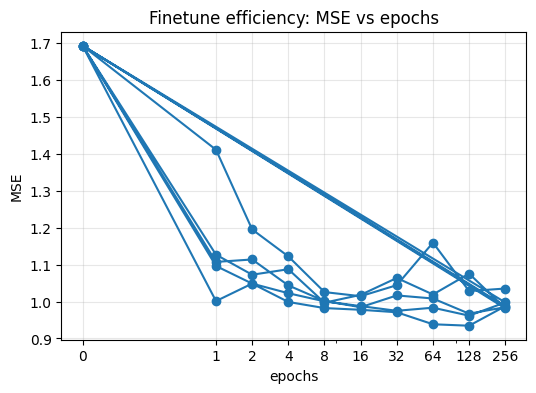

Saved efficiency-by-frac plot to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\pretrained_finetune\plots\finetune_full_finetune_efficiency_mse_by_frac.png


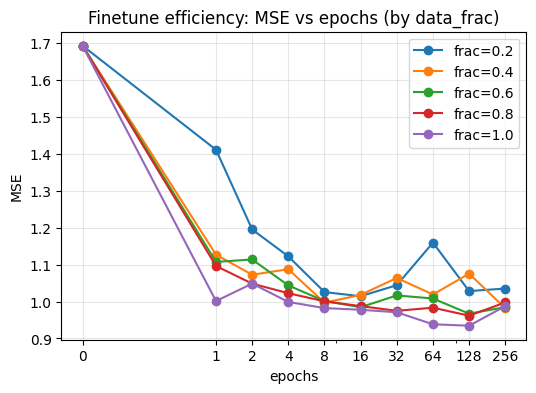

In [78]:
# Run full finetune + unified assessment
RUN_FINETUNE_FULL = True
FINETUNE_EPOCH_SWEEP = [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]
FINETUNE_DATA_FRAC_SWEEP = [1.0, 0.8, 0.6, 0.4, 0.2]
FINETUNE_LR = cfg.finetune_lr

RUN_FINETUNE_SAMPLES = False
FINETUNE_N_SAMPLES = 50
FINETUNE_SAMPLE_FRAC = 0.2
FINETUNE_SAMPLE_METRIC = "mse"
SHOW_FINETUNE_PLOTS = True

RUN_SAMPLE_FRAC_SWEEP = False
SAMPLE_FRAC_SWEEP = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
SAMPLE_FRAC_SWEEP_METRIC = "mse"

if RUN_FINETUNE_FULL:
    finetune_runs = []
    finetune_metrics = None

    for data_frac in FINETUNE_DATA_FRAC_SWEEP:
        for epochs in FINETUNE_EPOCH_SWEEP:
            run = run_finetune_variant(
                "full_finetune",
                SPLITS,
                cfg,
                paths,
                PRETRAIN_RUN,
                data_frac=data_frac,
                epochs=epochs,
                lr=FINETUNE_LR,
            )
            if run:
                finetune_runs.append(run)

    if finetune_runs:
        # Evaluate per-year buckets for the last run in the sweep
        eval_out = evaluate_finetune_run(finetune_runs[-1], SPLITS, cfg, paths)
        if eval_out is not None:
            finetune_metrics, finetune_path = eval_out
            print(f"Finetune metrics saved to {finetune_path}")

        # Boxplots using the last run in the sweep
        model, artifacts, _ = resolve_artifacts_and_model(finetune_runs[-1], paths)
        if RUN_FINETUNE_SAMPLES:
            samples_df = evaluate_bucket_samples(
                model=model,
                artifacts=artifacts,
                splits=SPLITS,
                cfg=cfg,
                method=finetune_runs[-1]["variant"],
                n_samples=FINETUNE_N_SAMPLES,
                sample_frac=FINETUNE_SAMPLE_FRAC,
                replace=True,
                seed=cfg.seed,
            )
            if samples_df is not None and not samples_df.empty:
                samples_path = paths.results / (
                    f"finetune_{finetune_runs[-1]['variant']}_samples_ns{FINETUNE_N_SAMPLES}_frac{FINETUNE_SAMPLE_FRAC}.csv"
                )
                samples_df.to_csv(samples_path, index=False)
                print(f"Sampled finetune metrics saved to {samples_path}")
                plot_zero_shot_boxplots(
                    samples_df,
                    metric=FINETUNE_SAMPLE_METRIC,
                    out_dir=paths.plots,
                    show=SHOW_FINETUNE_PLOTS,
                    prefix=f"finetune_{finetune_runs[-1]['variant']}",
                    title_prefix=f"Finetune {finetune_runs[-1]['variant']}"
                )

        runs_df = summarize_finetune_runs(finetune_runs)
        plot_finetune_efficiency(
            runs_df,
            metric="mse",
            out_dir=paths.plots,
            show=SHOW_FINETUNE_PLOTS,
        )
        plot_finetune_efficiency_by_frac(
            runs_df,
            metric="mse",
            out_dir=paths.plots,
            show=SHOW_FINETUNE_PLOTS,
            prefix=f"finetune_{finetune_runs[-1]['variant']}"
        )

        if RUN_SAMPLE_FRAC_SWEEP:
            sweep_summary = sample_frac_sweep_summary(
                model=model,
                artifacts=artifacts,
                splits=SPLITS,
                cfg=cfg,
                method=finetune_runs[-1]["variant"],
                sample_fracs=SAMPLE_FRAC_SWEEP,
                n_samples=FINETUNE_N_SAMPLES,
                metric=SAMPLE_FRAC_SWEEP_METRIC,
                seed=cfg.seed,
            )
            if sweep_summary is not None and not sweep_summary.empty:
                sweep_path = paths.results / (
                    f"finetune_{finetune_runs[-1]['variant']}_sample_frac_sweep_{SAMPLE_FRAC_SWEEP_METRIC}.csv"
                )
                sweep_summary.to_csv(sweep_path, index=False)
                plot_sample_frac_sweep(
                    sweep_summary,
                    metric=SAMPLE_FRAC_SWEEP_METRIC,
                    out_dir=paths.plots,
                    show=SHOW_FINETUNE_PLOTS,
                    prefix=f"finetune_{finetune_runs[-1]['variant']}"
                )

        if finetune_metrics is not None:
            aggregate_results(globals().get("zero_shot_df"), finetune_metrics, paths)
    else:
        print("No finetune runs completed.")
else:
    print("Skipped full finetune run.")

## Results aggregation stub
Combine zero-shot and finetune results into a tidy table with method/year/metric/data_frac/epochs/wall_time fields, and persist CSV/JSON under `artifacts/results/`.

In [63]:
def aggregate_results(zero_shot_df: pd.DataFrame | None, finetune_df: pd.DataFrame | None, paths: NotebookPaths):
    """Combine zero-shot + finetune outputs and persist tidy CSV/JSON."""
    frames = []
    if zero_shot_df is not None:
        frames.append(zero_shot_df.assign(method="zero_shot"))
    if finetune_df is not None:
        frames.append(finetune_df)

    if not frames:
        print("No results to aggregate yet.")
        return None

    all_results = pd.concat(frames, ignore_index=True)
    csv_path = paths.results / "all_results.csv"
    json_path = paths.results / "all_results.json"
    all_results.to_csv(csv_path, index=False)
    all_results.to_json(json_path, orient="records")
    return all_results, csv_path, json_path


## Plotting stub
Reserved for metric-vs-year overlays, delta vs zero-shot, metric vs epochs/data_frac, efficiency plots, and aggregate distributions. Use `matplotlib`/`seaborn` once results tables are available.

In [64]:
def plot_placeholders(results: pd.DataFrame | None, paths: NotebookPaths):
    """Stub to hold plotting calls once results exist."""
    if results is None or results.empty:
        print("No results to plot yet.")
        return None
    # TODO: add seaborn/matplotlib visualizations per plan (yearly curves, deltas, epoch/data_frac sweeps, efficiency).
    return None


## Reporting / notes
Use this section to capture configs (seed, lr schedules, data_frac, epoch budgets), checkpoints used, and observations for each variant. Summaries, open questions, and next steps belong here.